# 🤖 1. Full Preprocessing Deep Learning Models - with NO Dropouts
**Deep learning models for retinal fundus image classification and refractive error regression**

The purpose of this notebook is to implement and evaluate deep learning models for both binary myopia classification and spherical equivalent (SE) regression using fully preprocessed retinal fundus images. The dataset contains clinically acquired retinal fundus images linked to demographic and refractive information extracted from ophthalmological consultations. It consists of 2,126 fundus images.

In this stage of the project, the objectives are:
- To evaluate a lightweight CNN architecture for automated binary myopia classification.
- To evaluate a second CNN architecture adapted for refractive error regression using spherical equivalent (SE) values.

To analyze how fully preprocessed retinal fundus images behave in both classification and regression tasks.
These initial experiments will serve as a foundation for more advanced approaches (e.g., finding out which preprocessing step pushed models to do better), while highlighting the trade-offs between model complexity, training time, and classification accuracy.

The relevance of this work lies in its potential contribution to automated ophthalmology screening tools, aiming for faster and more accessible detection of myopia.

## ⚙️ 1. Setting up

Create a deterministic Train/Val/Test split (satrtified)

Building a DataFrame with image paths and labels. Splitting the dataset into train, validation, and test sets (80/10/10) with stratification to keep class balance (avoids bias if one class bigger than the other).

In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd
# from sklearn.model_selection import train_test_split - not necessary, we'll be importing splits now
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os, random

# Load configurable project paths ============================================================

# Project root detection
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "config.yaml").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("config.yaml was not found. Make sure it is located in the project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (
    load_config,
    get_paths,
    get_experiment_paths,
    validate_main_structure,
    validate_experiment_paths,
    print_paths
)

cfg = load_config(PROJECT_ROOT / "config.yaml")

paths = get_paths(cfg)
validate_main_structure(paths)

exp_paths = get_experiment_paths(cfg, "full_preproc_no_dropout")
validate_experiment_paths(exp_paths)

# General settings ===========================================================

SEED = int(cfg["settings"]["seed"])
IMG_SIZE = tuple(cfg["settings"]["image_size"]) #from config.yaml - must match the preprocessed size
BATCH = int(cfg["settings"]["batch_size"]) #from config.yaml - number of images preprocessed in each training step

tf.keras.utils.set_random_seed(SEED)  #locks Python, NumPy and TF seed
tf.config.experimental.enable_op_determinism() #makes same deterministic ops

# Paths ===========================================================

TABLE_PATH = exp_paths["table"]

SPLIT_DIR_CLASSF = exp_paths["split_classification"]
SPLIT_DIR_REGRSS = exp_paths["split_regression"]

MODELS_DIR_FULL = exp_paths["models_experiment"]
MODELS_DIR_FULL.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Table path:", TABLE_PATH)
print("Classification splits:", SPLIT_DIR_CLASSF)
print("Regression splits:", SPLIT_DIR_REGRSS)
print("Models output:", MODELS_DIR_FULL)
print("IMG_SIZE:", IMG_SIZE)
print("BATCH:", BATCH)
print("SEED:", SEED)

df = pd.read_excel(TABLE_PATH)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Table path: C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\Tabla_MatchImagenesConDatosClinicos_FullPreproc.xlsx
Classification splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\FullPreproc
Regression splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Regression\FullPreproc
Models output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithoutDropout\FullPreproc
IMG_SIZE: (224, 224)
BATCH: 32
SEED: 42


In [2]:
# Keep only images with valid path and existent SE targets
df = df[df["image_path"].notna()].copy()
df = df[df["target_SE"].notna()].copy()
df = df[df["class_label"].notna()].copy()

df["image_path"] = df["image_path"].astype(str)
df["patient_id"] = df["patient_id"].astype(str).str.upper().str.strip()
df["target_SE"] = pd.to_numeric(df["target_SE"], errors="coerce")
df["class_label"] = pd.to_numeric(df["class_label"], errors="coerce").astype("int32")

df = df.dropna(subset=["image_path", "patient_id", "target_SE", "class_label"])

print("Total valid images (with SE):", len(df))
print("\nClassification label balance (0 = non-myopic, 1 = myopic)")
print(df["class_label"].value_counts())
print("\nTarget SE summary:")
print(df["target_SE"].describe())

df.head()

Total valid images (with SE): 2126

Classification label balance (0 = non-myopic, 1 = myopic)
class_label
0    1645
1     481
Name: count, dtype: int64

Target SE summary:
count    2126.000000
mean        0.021696
std         2.109061
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         9.000000
Name: target_SE, dtype: float64


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,¿Revisar?,Ultimavisita_dt,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
1,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
2,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51,...,NO,2023-12-11,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
3,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51,...,NO,2023-12-11,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
4,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26,...,NO,2023-04-12,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance


In [3]:
df["class_label"] = df["class_label"].astype("int32")
print("Total valid images (with SE):", len(df))
print("\nClassification label balance (0 = non-myopic, 1 = myopic)")
print(df["class_label"].value_counts())
print("\nTarget SE summary:")
print(df["target_SE"].describe())

df.head()

Total valid images (with SE): 2126

Classification label balance (0 = non-myopic, 1 = myopic)
class_label
0    1645
1     481
Name: count, dtype: int64

Target SE summary:
count    2126.000000
mean        0.021696
std         2.109061
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.750000
max         9.000000
Name: target_SE, dtype: float64


,image_path,filename,patient_id,image_date_raw,image_date,modality,eye,nhc,FechaNacimiento,Edad,...,¿Revisar?,Ultimavisita_dt,match_type,target_SE,class_label,original_image_path,preprocessing,image_size,clahe_applied,clahe_mode
0,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165654_Color_R_001.jpg,A6138,17092024,2024-09-17,Color,R,A6138,2020-06-03,6,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
1,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6138_17092024_165721_Color_L_001.jpg,A6138,17092024,2024-09-17,Color,L,A6138,2020-06-03,6,...,SI,2024-09-17,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
2,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191157_IR_R_001.jpg,A6140,11122023,2023-12-11,IR,R,A6140,1975-10-06,51,...,NO,2023-12-11,id+date,-2.250,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
3,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6140_11122023_191221_IR_L_001.jpg,A6140,11122023,2023-12-11,IR,L,A6140,1975-10-06,51,...,NO,2023-12-11,id+date,-0.625,1,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance
4,C:\Users\paula\0B_TFGBiomed\Images\01_FullPrep...,A6142_12042023_153339_Color_R_001.jpg,A6142,12042023,2023-04-12,Color,R,A6142,2000-07-08,26,...,NO,2023-04-12,id+date,0.000,0,C:\Users\paula\0B_TFGBiomed\Images\00_OG_Galdo...,full,224,True,luminance


Dataset and target distribution

The dataset contains **2,126 valid images** with available SE and binary myopia labels. The class distribution is clearly imbalanced: **1,645 normal images** and **481 myopic images**, meaning that normal cases represent approximately **77%** of the dataset.

This imbalance must be considered when interpreting classification accuracy. A model that predicted every test image as normal would already obtain an accuracy close to **78%**, so accuracy alone is not enough to evaluate the classifier. AUC, Average Precision, the Precision-Recall curve and the confusion matrix are more informative.

The SE distribution is also highly concentrated around **0 D**, with a median of **0 D**, but includes extreme values down to **-20.375 D** and up to **9 D**. This explains why regression is challenging: a model can obtain a moderate MAE by predicting values close to the central tendency, without actually learning meaningful image-based SE information.

Compared with the previous notebooks, this dataset inspection is consistent: the same imbalance and SE concentration appear again. Therefore, any improvement or worsening in this notebook should be attributed mainly to the modelling/preprocessing configuration, not to a different underlying dataset.


#### 1.2. Train/Val/Test split

In [4]:
# Stratified 80/10/10 split across patients, in 00_CreatePatientLevelSplits_Classf_Regrss.ipynb
# Stratification is done using the classification label from the matches table to keep myopia/normal/mixed balance across splits

train_df_classf = pd.read_csv(SPLIT_DIR_CLASSF / "train.csv")
val_df_classf   = pd.read_csv(SPLIT_DIR_CLASSF / "val.csv")
test_df_classf  = pd.read_csv(SPLIT_DIR_CLASSF / "test.csv")

train_df_regrss = pd.read_csv(SPLIT_DIR_REGRSS / "train.csv")
val_df_regrss   = pd.read_csv(SPLIT_DIR_REGRSS / "val.csv")
test_df_regrss  = pd.read_csv(SPLIT_DIR_REGRSS / "test.csv")

print("Classification split sizes:")
print("Train:", len(train_df_classf))
print("Val:  ", len(val_df_classf))
print("Test: ", len(test_df_classf))

print("\nRegression split sizes:")
print("Train:", len(train_df_regrss))
print("Val:  ", len(val_df_regrss))
print("Test: ", len(test_df_regrss))


def check_no_overlap(train_df, val_df, test_df, column, name):
    train_values = set(train_df[column].astype(str))
    val_values   = set(val_df[column].astype(str))
    test_values  = set(test_df[column].astype(str))

    assert len(train_values & val_values) == 0, f"{name}: overlap between train and val"
    assert len(train_values & test_values) == 0, f"{name}: overlap between train and test"
    assert len(val_values & test_values) == 0, f"{name}: overlap between val and test"

    print(f"OK: no {name} overlap across train/val/test.")


# Check patient-level separation
check_no_overlap(train_df_classf, val_df_classf, test_df_classf, "patient_id", "classification patient")
check_no_overlap(train_df_regrss, val_df_regrss, test_df_regrss, "patient_id", "regression patient")

# Check exact image separation too
check_no_overlap(train_df_classf, val_df_classf, test_df_classf, "image_path", "classification image")
check_no_overlap(train_df_regrss, val_df_regrss, test_df_regrss, "image_path", "regression image")

print("\nClassification label balance:")
print("Train:")
print(train_df_classf["class_label"].value_counts(normalize=True))
print("Val:")
print(val_df_classf["class_label"].value_counts(normalize=True))
print("Test:")
print(test_df_classf["class_label"].value_counts(normalize=True))

print("\nRegression target SE summary:")
print("Train:")
print(train_df_regrss["target_SE"].describe())
print("Val:")
print(val_df_regrss["target_SE"].describe())
print("Test:")
print(test_df_regrss["target_SE"].describe())

Classification split sizes:
Train: 1701
Val:   211
Test:  214

Regression split sizes:
Train: 1700
Val:   209
Test:  217
OK: no classification patient overlap across train/val/test.
OK: no regression patient overlap across train/val/test.
OK: no classification image overlap across train/val/test.
OK: no regression image overlap across train/val/test.

Classification label balance:
Train:
class_label
0    0.771899
1    0.228101
Name: proportion, dtype: float64
Val:
class_label
0    0.781991
1    0.218009
Name: proportion, dtype: float64
Test:
class_label
0    0.780374
1    0.219626
Name: proportion, dtype: float64

Regression target SE summary:
Train:
count    1700.000000
mean        0.006029
std         2.173365
min       -20.375000
25%        -0.250000
50%         0.000000
75%         0.625000
max         7.750000
Name: target_SE, dtype: float64
Val:
count    209.000000
mean       0.069976
std        1.860834
min      -14.000000
25%       -0.375000
50%        0.000000
75%        0.750

The train/validation/test split is correctly loaded for both tasks. The classification split contains **1,701 training images**, **211 validation images** and **214 test images**. The regression split contains **1,700 training images**, **209 validation images** and **217 test images**.

The checks confirm that there is **no patient overlap** and **no image overlap** between train, validation and test sets. 

The class proportions are also preserved across the classification splits: the test set contains approximately **78% normal images** and **22% myopic images**. Therefore, the same majority-class baseline of around **0.78 accuracy** remains relevant when interpreting the classification model.

For regression, the SE summaries remain centred around 0 D across train, validation and test. This again reinforces that MAE must be interpreted with caution, because a mean-like predictor can appear acceptable even when R² is close to zero.


#### 1.3. Building TF datasets

Now we move onto building efficient TensorFlow datasets (tf.data pipeline) from image paths and labels, applying decoding, resizing, batching, and lightweight data augmentations for training.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE #allows for paralelism automation

def decode_img(path, y):
    img = tf.io.read_file(path) #reades pic as bytes
    img = tf.image.decode_jpeg(img, channels=3) # decodes jpg into RGB tensor
    img = tf.image.convert_image_dtype(img, tf.float32)  # converts to float [0,1]
    img = tf.image.resize(img, IMG_SIZE, method='bilinear') #rescales to 224x224
    return img, y #gives pic+corresponding label/target

# Lightweight augmentations
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), #hozt flip (imitates eye flip)
    tf.keras.layers.RandomRotation(0.02), #slight rotation
    tf.keras.layers.RandomZoom(0.05), #slight random zoom
])


In [6]:
def make_classification_ds(csv_path, training=False): #creating the TensorFlow dataset for binary classf
    df_split = pd.read_csv(csv_path)
    paths = df_split["image_path"].astype(str).values
    labels = df_split["class_label"].astype("float32").values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, y: decode_img(p, y), num_parallel_calls=AUTOTUNE) #applies decode_img on each image
    if training: #if trainig, it shuffles and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)  #(aumentos)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE) #prefetching makes pipeline faster
    return ds

def make_regression_ds(csv_path, training=False): #creating the TensorFlow dataset for SE regrss
    df_split = pd.read_csv(csv_path)
    
    paths = df_split["image_path"].astype(str).values
    targets = df_split["target_SE"].astype("float32").values
    
    ds = tf.data.Dataset.from_tensor_slices((paths, targets))
    ds = ds.map(lambda p, y: decode_img(p, y), num_parallel_calls=AUTOTUNE) #applies decode_img on each image
    
    if training: #if trainig, it shuffles and applies augmentations 
        ds = ds.shuffle(8192, seed=SEED, reshuffle_each_iteration=True) 
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)  #(aumentos)
    ds = ds.batch(BATCH).prefetch(AUTOTUNE) #prefetching makes pipeline faster
    return ds

In [7]:
train_ds_classf = make_classification_ds(SPLIT_DIR_CLASSF / "train.csv", training=True) #shuffle + augmentations
val_ds_classf = make_classification_ds(SPLIT_DIR_CLASSF / "val.csv", training=False) #decode + bacthing (no augs)
test_ds_classf = make_classification_ds(SPLIT_DIR_CLASSF / "test.csv", training=False) #decode + batching (no augs)

train_ds_regrss = make_regression_ds(SPLIT_DIR_REGRSS / "train.csv", training=True) #shuffle + augmentations
val_ds_regrss = make_regression_ds(SPLIT_DIR_REGRSS / "val.csv", training=False) #decode + bacthing (no augs)
test_ds_regrss = make_regression_ds(SPLIT_DIR_REGRSS / "test.csv", training=False) #decode + batching (no augs)

## 🧩 2. The models

#### 🟢 2.1. First model: small_cnn_classification
Now, we define our first small CNN for binary classification, that is CPU friendly and compiles it with Adam and binary cross-entropy, adds AUC/accuracy metrics, uses early stopping and learning-rate reduction on plateau, computes class weights from the train split, and trains the model with the tf.data pipelines.

In [8]:
def build_small_cnn_classf(input_shape=(224,224,3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs) #progressively extracts characteristics
    x = layers.MaxPool2D()(x) #reduces resolution and makes more compact/robust representation
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x) #zero-padding on borders so input is same size as output (in case kernel and input are different sizes?)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x) #compacts activation maps into mean value (lees params and less overfitting than Flatten)
    #x = layers.Dropout(0.3)(x) #randomly switches off 30% of neurons while training
    outputs = layers.Dense(1, activation="sigmoid")(x) #binary exit (1 is the probability of myopia)
    return keras.Model(inputs, outputs)

model_classf = build_small_cnn_classf()

model_classf.compile(optimizer=keras.optimizers.Adam(1e-3), #Adam optimizer with lr=1e-3
              loss="binary_crossentropy", #adecuate for binary classification with sigmoid
              metrics=[keras.metrics.AUC(name="auc"), "accuracy"]) #AUC and accuracy metrics  

In [9]:
model_classf.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

#### ⏱️2.1.2. Callbacks for classification
Training monitors (earlystopping and learning-rate) scheduling for stability and later use.

Class weights are correction factors used during training to handle class' number differences: errors when choosing the minority class are penalized more strongly, while errors on the majority class are penalized less. This ensures the model pays equal attention to both classes despite unequal sample counts.

In [10]:
# Building callbacks for later use
cb_classf = [ 
    keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True), #if AUC is not better after 5 epochs, goes back to previous weights
    keras.callbacks.ReduceLROnPlateau( monitor="val_auc", mode="max", factor=0.3, patience=2),#if AUC stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
]

from sklearn.utils.class_weight import compute_class_weight

# Load train split
train_df_classf = pd.read_csv(SPLIT_DIR_CLASSF / "train.csv")

classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=train_df_classf["class_label"].astype(int).values) #calcultes inverse weights to teh frecuency of each class
class_weight = {0: float(weights[0]), 1: float(weights[1])} #dictionary understood by keras
print("Class weights:", class_weight)

Class weights: {0: 0.6477532368621478, 1: 2.1920103092783507}


Class weights

The class weights are the same as in the previous classification notebooks: approximately **0.65 for normal images** and **2.19 for myopic images**. This means that errors on myopic samples are penalized more strongly during training.

This weighting is justified because myopia is the minority class. However, it also helps explain the later behaviour of the classifier: the model becomes more willing to predict myopia, which increases myopia recall but also produces many false positives among normal images.

This is especially relevant in this no-Dropout notebook because the final confusion matrix shows a clear tendency to overpredict the myopic class.


#### 2.1.3 Training classification model

In [11]:
history_classf = model_classf.fit(train_ds_classf, validation_data=val_ds_classf, epochs=10, callbacks=cb_classf, class_weight=class_weight) 
# Proper training using our tf.data pipelines (train_ds, val_ds):
# Applies class_weight to penalize errors on the minority class more strongly
# Runs for up to 10 epochs, but EarlyStopping may stop earlier if val_auc does not improve

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.5923 - auc: 0.4392 - loss: 0.6979 - val_accuracy: 0.7488 - val_auc: 0.5402 - val_loss: 0.6890 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.6820 - auc: 0.5645 - loss: 0.7010 - val_accuracy: 0.4597 - val_auc: 0.5451 - val_loss: 0.6905 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.4489 - auc: 0.5680 - loss: 0.6955 - val_accuracy: 0.3697 - val_auc: 0.5491 - val_loss: 0.7007 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.2588 - auc: 0.5398 - loss: 0.6887 - val_accuracy: 0.2322 - val_auc: 0.5448 - val_loss: 0.7057 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.2843 - auc: 0.5249 - loss: 0.6983 - val_accuracy: 0.7441 - val_auc: 0.5368 - val_loss: 0.6737 - learning_rate: 0.0010
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.7578 - auc: 0.5661 - lo

In [12]:
test_metrics_classf = history_classf.model.evaluate(test_ds_classf, return_dict=True)
test_metrics_classf

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 326ms/step - accuracy: 0.3229 - auc: 0.5604 - loss: 0.7108


{'accuracy': 0.3504672944545746,
 'auc': 0.5855523347854614,
 'loss': 0.7078583836555481}

Note: if overfitting is seen we may increase the dropout rate, add L2 on Conv2D or increase augmentations.

Classification test metrics

The no-Dropout full preprocessing classifier obtains a test accuracy of **0.350**, a Keras test AUC of approximately **0.586**, and a later sklearn AUC of **0.591**. The small difference between the two AUC values is expected because they are computed through slightly different evaluation pathways, but both point to the same conclusion: the model only separates the two classes weakly.

The accuracy is very low compared with the majority-class baseline of approximately **0.78**. This does not necessarily mean that the model predicts randomly; rather, it indicates that the default threshold of **0.5** is poorly calibrated for this class-weighted model. The model is pushed towards predicting myopia more often, sacrificing specificity.

Compared with the previous selective preprocessing classification notebook with Dropout, this full preprocessing no-Dropout model performs worse than the best selective scenarios. The best selective AUC was obtained by **A_Raw_minimal** with **AUC = 0.622**, while this model reaches only **AUC = 0.591**. Its AP is also lower than the best selective AP obtained with **C_GeoNorm_Illum_NoAug**.

Therefore, removing Dropout does not solve the classification problem under full preprocessing. In fact, the no-Dropout full preprocessing configuration appears slightly weaker than the best selective preprocessing results.


-> The first classification evaluation already shows that the no-Dropout full preprocessing model is not performing well enough. The test AUC is only slightly above random and the accuracy is far below the majority-class baseline. 
This suggests that simply removing Dropout from the full preprocessing small CNN does not improve classification. The model still struggles to learn robust image features associated with myopia.


#### 🟠 2.2 Second model: small_cnn_regression
The same lightweight CNN backbone is adapted for refractive error regression by replacing the sigmoid classification head with a linear output neuron predicting continuous spherical equivalent (SE) values.

In [13]:
def build_small_cnn_regrss(input_shape=(224, 224, 3)):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs) #progressively extracts characteristics
    x = layers.MaxPool2D()(x) #reduces resolution and makes more compact/robust representation
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x) #zero-padding on borders so input is same size as output (in case kernel and input are different sizes?)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x) #compacts activation maps into mean value (lees params and less overfitting than Flatten)
    #x = layers.Dropout(0.3)(x) #randomly switches off 30% of neurons while training - NOT on this notebook
    outputs = layers.Dense(1, activation="linear")(x) # Regression output: one continuous value, e.g. -2.75 diopters
    return keras.Model(inputs, outputs)

model_regrss = build_small_cnn_regrss()

model_regrss.compile(optimizer=keras.optimizers.Adam(1e-3), #Adam optimizer with low error 
        loss="mse", #adecuate for regression calculations (Mean Squared Error)
        metrics=[keras.metrics.MeanAbsoluteError(name="mae"), keras.metrics.MeanSquaredError(name="mse")]) #Mean Absolute Error and accuracy metrics

Let's see how our model did:

In [14]:
model_regrss.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

#### ⏱️2.2.2. Callbacks for regression

In [15]:
cb_regrss = [ 
    keras.callbacks.EarlyStopping(monitor="val_mae", mode="min", patience=5, restore_best_weights=True), #if MAE not lower after 5 epochs, stop training and go back to best weights
    keras.callbacks.ReduceLROnPlateau( monitor="val_mae", mode="min", factor=0.3, patience=2),#if MAE stays the same value after 2 epochs, LR gets reduced multiplying it by 0.3
]

#### 2.2.3 Training regression model

In [16]:
history_regrss = model_regrss.fit(train_ds_regrss, validation_data=val_ds_regrss, epochs=10, callbacks=cb_regrss) 
# Proper training using our tf.data regression pipelines
# The model learns to predict a continuous SE value in diopters
# Runs for up to 10 epochs, but EarlyStopping may stop it earlier if validation MAE does not improve.

Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - loss: 4.2212 - mae: 1.1820 - mse: 4.2212 - val_loss: 3.4553 - val_mae: 1.0325 - val_mse: 3.4553 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - loss: 4.9633 - mae: 1.2651 - mse: 4.9633 - val_loss: 3.4374 - val_mae: 0.9969 - val_mse: 3.4374 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - loss: 4.6009 - mae: 1.2316 - mse: 4.6009 - val_loss: 3.4288 - val_mae: 1.0054 - val_mse: 3.4288 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - loss: 4.7947 - mae: 1.2827 - mse: 4.7947 - val_loss: 3.4159 - val_mae: 1.0116 - val_mse: 3.4159 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - loss: 4.1758 - mae: 1.1952 - mse: 4.1758 - val_loss: 3.4139 - val_mae: 1.0455 - val_mse: 3.4139 - learning_rate: 3.0000e-04
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - loss: 4.6021 - mae: 1.2524 - mse: 4.6021 - val_loss: 3.3865 - val_mae: 1.0636 - val

In [17]:
test_metrics_regrss = history_regrss.model.evaluate(test_ds_regrss, return_dict=True)
test_metrics_regrss

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 304ms/step - loss: 4.0042 - mae: 1.1859 - mse: 4.0042


{'loss': 3.25010347366333, 'mae': 1.028565526008606, 'mse': 3.25010347366333}

Regression test metrics

The no-Dropout full preprocessing regression model obtains **MAE = 1.029 D**, **RMSE = 1.803 D** and **R² = -0.0009** on the test set (below).

The R² value is essentially zero, meaning that the model does not explain SE variability better than a simple baseline that predicts a constant value. Therefore, even though the MAE is around 1 D, the model should not be interpreted as learning a useful image-to-SE relationship.

Compared with the previous selective preprocessing regression notebook with Dropout, this result is actually worse in terms of MAE and RMSE. In the selective notebook, the best MAE was approximately **0.752 D** for **A_Raw_minimal**, and all selective scenarios had RMSE around **1.63 D**. Here, the full preprocessing no-Dropout model reaches a higher MAE and RMSE.

However, the main conclusion is the same across both regression notebooks: **R² remains approximately 0**, so the model still collapses towards a mean-like prediction and does not capture clinically meaningful SE variation from the images.


-> The regression model obtains a test MAE close to **1.03 D**, but the more important result is the near-zero R² later obtained in the dedicated regression evaluation. This means that the model is not learning a useful SE prediction. As in the previous regression notebooks, the model appears to predict values close to the centre of the SE distribution instead of capturing the true refractive variability.


In [18]:
# Save trained models
CLASSF_MODEL_PATH = MODELS_DIR_FULL / "small_cnn_classification_without_dropout_fullpreproc.keras"
REGRSS_MODEL_PATH = MODELS_DIR_FULL / "small_cnn_regression_without_dropout_fullpreproc.keras"

model_classf.save(CLASSF_MODEL_PATH)
model_regrss.save(REGRSS_MODEL_PATH)

print("Classification model saved at:", CLASSF_MODEL_PATH)
print("Regression model saved at:", REGRSS_MODEL_PATH)

Classification model saved at: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithoutDropout\FullPreproc\small_cnn_classification_without_dropout_fullpreproc.keras
Regression model saved at: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithoutDropout\FullPreproc\small_cnn_regression_without_dropout_fullpreproc.keras


## 📊 3. Results of classification and regression models

#### 📈 3.1 Plot histories
Plotting training and validation curves (AUC, accuracy, or loss) for one or multiple Keras models, making it easy to compare performance across epochs.

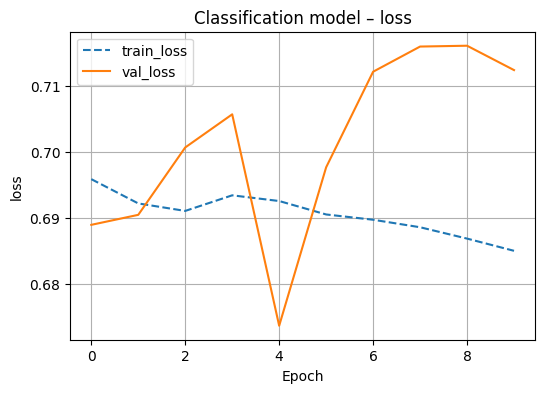

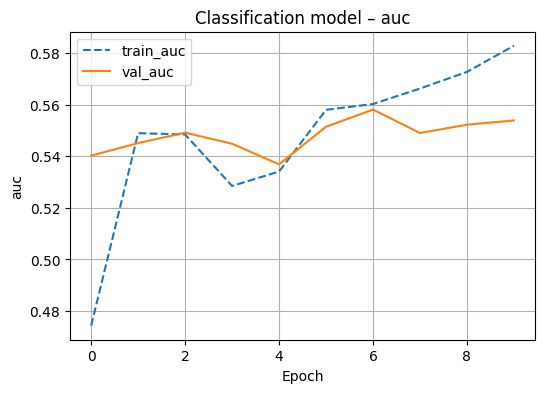

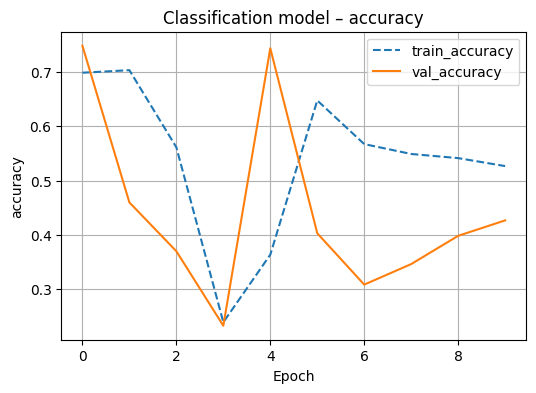

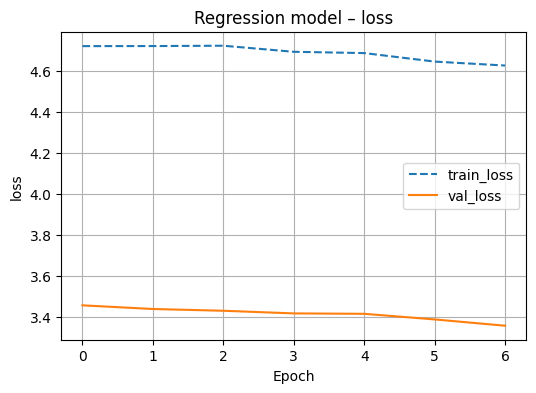

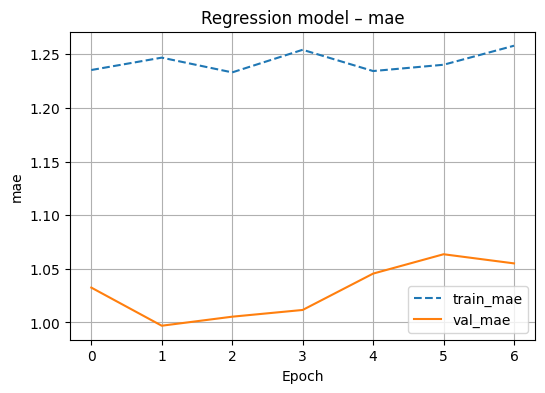

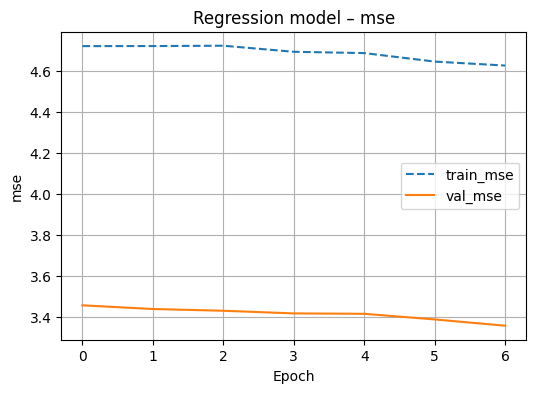

In [19]:
def plot_histories(history, metrics, title):
    #histories: list of keras History objects returned after training
    #metrics: e.g. "auc" | "accuracy" | "loss" -  metrics to visualize during training
    #title: list of names e.g. ["Classification", "Regression"]

    for metric in metrics:
        plt.figure(figsize=(6,4))
        
        if metric in history.history:
            plt.plot(history.history[metric], linestyle="--", label=f"train_{metric}")
        
        if f"val_{metric}" in history.history:
            plt.plot(history.history[f"val_{metric}"], label=f"val_{metric}")
        
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.title(f"{title} – {metric}")
        plt.legend()
        plt.grid(True)
        plt.show()

#classf
plot_histories(
    history_classf,
    metrics=["loss", "auc", "accuracy"],
    title="Classification model"
)

#regrss
plot_histories(
    history_regrss,
    metrics=["loss", "mae", "mse"],
    title="Regression model"
)


The classification training curves show unstable accuracy and a validation AUC that remains low, around **0.54–0.56**. Although the training AUC increases slightly, the validation AUC does not show a strong or consistent improvement. This suggests **weak learning rather than successful generalization.**

The classification loss remains close to **0.69–0.71**, which is consistent with a binary classifier that has difficulty separating the two classes. The absence of Dropout does not produce a clear improvement in learning dynamics.

The regression curves show validation MAE values around **1.0 D**, with limited improvement after the first epochs. The model does not show a strong overfitting pattern; instead, the curves suggest that it converges to a simple solution with limited predictive power.

Compared with the selective preprocessing regression notebook, the training behaviour is conceptually similar: the model trains without obvious instability, but the test R² later confirms that the learned solution is not useful for SE prediction.


-> The training curves do not show a strong successful learning pattern. The classification validation AUC stays low and unstable, while the regression validation MAE remains around 1 D. The important point is that removing Dropout does not visibly improve training dynamics. The model does not overfit dramatically, but it also does not learn strong discriminative or predictive features.


#### 🧪 3.2 Collect predictions & eval on test set
Evaluating trained models on the test set, collecting predictions, plotting ROC and Precision–Recall curves, showing the confusion matrix if there is one, and returning metrics such as AUC, AP, accuracy, and a classification report.

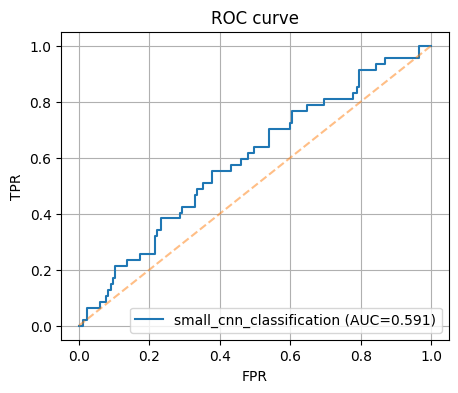

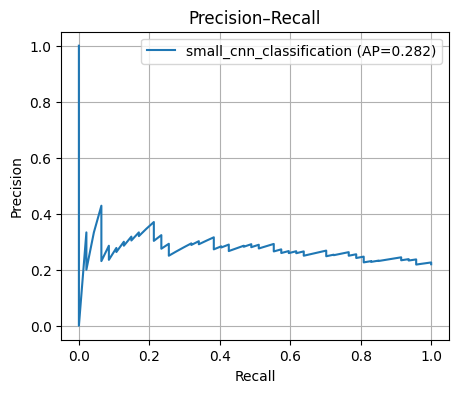

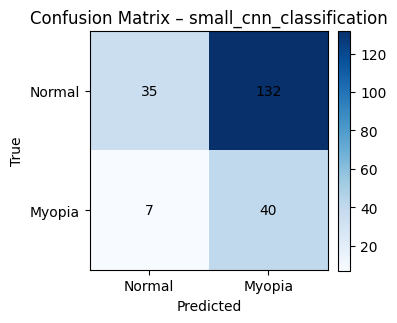

              precision    recall  f1-score   support

      Normal       0.83      0.21      0.33       167
      Myopia       0.23      0.85      0.37        47

    accuracy                           0.35       214
   macro avg       0.53      0.53      0.35       214
weighted avg       0.70      0.35      0.34       214



In [20]:
#CLASSIFICATION:

from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

def collect_classification_preds(model, ds): #dataset as ds
    y_true, y_score = [], [] #true labels 1 or 0; probabilities of model 0-1
    
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_score.extend(p.tolist())
    
    y_true = np.array(y_true).astype(int)
    y_score = np.array(y_score).astype(float)
    
    return y_true, y_score

def evaluate_classification_on_test(name, model, test_ds, threshold=0.5, show_plots=True):
    y_true, y_score = collect_classification_preds(model, test_ds)
    y_pred = (y_score >= threshold).astype(int)

    #Metric 1: ROC / PR
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    #Metric 2: Confusion matrix & report
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Myopia"]
    )

    if show_plots:
        # ROC curve: sensitivity to false positives (True Positive Rate vs False Positive Rate)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
        plt.plot([0,1], [0,1], "--", alpha=0.5)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title("ROC curve")
        plt.grid(True)
        plt.legend()
        plt.show()

        # PR: precission vs recall
        plt.figure(figsize=(5,4))
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall")
        plt.grid(True)
        plt.legend()
        plt.show()

        # Confusion matrix: TP/TN/FP/FN
        plt.figure(figsize=(4,3.6))
        plt.imshow(cm, cmap="Blues")
        plt.title(f"Confusion Matrix – {name}")
        plt.xticks([0,1], ["Normal", "Myopia"])
        plt.yticks([0,1], ["Normal", "Myopia"])
        for i in range(2):
            for j in range(2):
                plt.text(j, i, cm[i,j], ha="center", va="center")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    return {
        "name": name,
        "AUC": float(roc_auc), #Quality of segreggation
        "AP": float(ap),
        "accuracy@0.5": float((y_pred == y_true).mean()), #% Correctness
        "confusion_matrix": cm,
        "report": report
    }

# Example usage:
res_classf = evaluate_classification_on_test(
    "small_cnn_classification",
    model_classf,
    test_ds_classf
)

print(res_classf["report"])

The classification ROC curve gives **AUC = 0.591**, confirming weak discrimination between normal and myopic images. The Precision-Recall curve gives **AP = 0.282**, which is only slightly above the myopia prevalence baseline of around **0.22**.

The confusion matrix and classification report are especially informative. The model correctly identifies **40 out of 47 myopic images**, giving a high myopia recall of **0.85**. However, it correctly identifies only **35 out of 167 normal images**, giving a very low normal recall of **0.21**. In other words, the model detects many myopic cases, but at the cost of incorrectly labelling many normal images as myopic.

This pattern is consistent with the use of class weights. The model appears to prefer avoiding false negatives in the myopic class, but this creates a large number of false positives. From a clinical perspective, this configuration could be interpreted as sensitive but not specific enough.


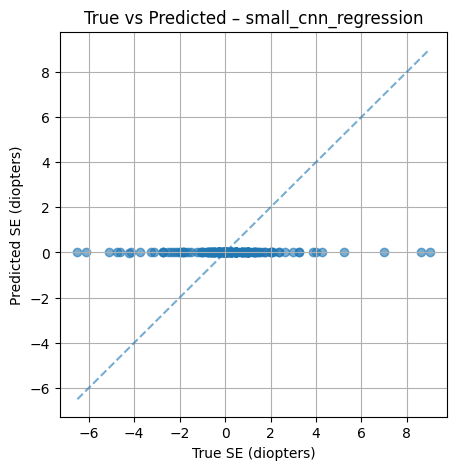

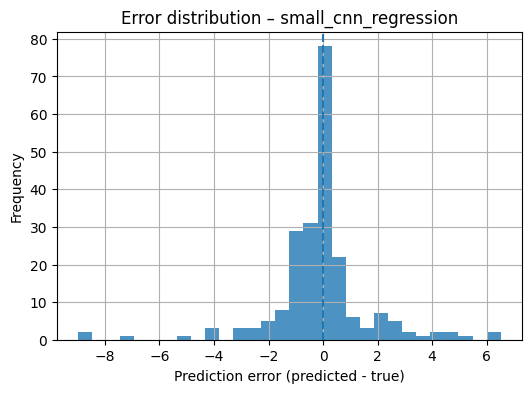

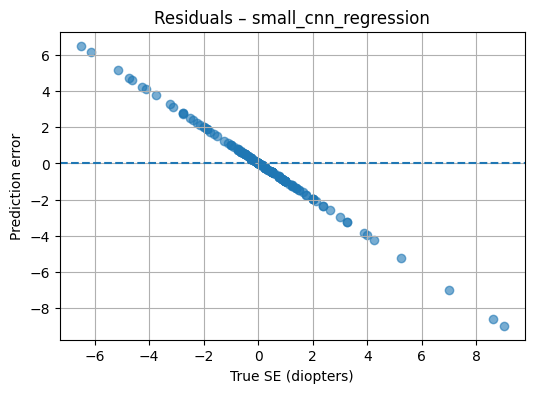

{'name': 'small_cnn_regression',
 'MAE': 1.0285656303094919,
 'MSE': 3.2501035130515157,
 'RMSE': 1.8028043468583927,
 'R2': -0.0009006691051103299}

In [21]:
#REGRESSION:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def collect_regression_preds(model, ds): #dataset as ds
    y_true, y_pred = [], [] # True SE values and predicted SE values
    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(p.tolist())
    
    y_true = np.array(y_true).astype(float)
    y_pred = np.array(y_pred).astype(float)
    
    return y_true, y_pred

def evaluate_regression_on_test(name, model, test_ds, show_plots=True):
    y_true, y_pred = collect_regression_preds(model, test_ds)
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    errors = y_pred - y_true

    if show_plots:
        # true vs predicted SE values
        plt.figure(figsize=(5,5))
        plt.scatter(y_true, y_pred, alpha=0.6)

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], "--", alpha=0.6)

        plt.xlabel("True SE (diopters)")
        plt.ylabel("Predicted SE (diopters)")
        plt.title(f"True vs Predicted – {name}")
        plt.grid(True)
        plt.show()
        
        # Distribution of prediction errors
        plt.figure(figsize=(6,4))
        plt.hist(errors, bins=30, alpha=0.8)
        plt.axvline(0, linestyle="--")
        plt.xlabel("Prediction error (predicted - true)")
        plt.ylabel("Frequency")
        plt.title(f"Error distribution – {name}")
        plt.grid(True)
        plt.show()

        # # Residual plot: relationship between prediction error and true SE
        plt.figure(figsize=(6,4))
        plt.scatter(y_true, errors, alpha=0.6)
        plt.axhline(0, linestyle="--")
        plt.xlabel("True SE (diopters)")
        plt.ylabel("Prediction error")
        plt.title(f"Residuals – {name}")
        plt.grid(True)
        plt.show()

    return {
        "name": name,
        "MAE": float(mae),
        "MSE": float(mse),
        "RMSE": float(rmse),
        "R2": float(r2)
    }

#Example usage:
res_regrss = evaluate_regression_on_test(
    "small_cnn_regression",
    model_regrss,
    test_ds_regrss
)

res_regrss

Regression plots and residuals
- The true-vs-predicted plot shows that the predicted SE values are concentrated in a narrow range, instead of following the real SE distribution. This indicates that the model is not learning to predict the full refractive range.
- The residual plot shows a structured pattern rather than random scatter. This is typical of a model that predicts values close to the centre of the distribution: it overestimates strongly negative SE values and underestimates positive SE values.
- The error histogram may appear centred around zero, but this does not imply good regression performance. It mainly reflects that the target distribution is itself centred near 0 D. The R² value close to zero confirms that the model is not explaining SE variability.

Compared with the selective regression notebook, the same failure mode appears again. The difference is that the full preprocessing no-Dropout model has worse MAE/RMSE, but the conceptual conclusion is identical: the CNN behaves like a mean predictor rather than a real SE regressor.


For the **small_cnn_classification without Dropout**, the ROC and Precision-Recall curves are not close to an ideal classifier. The test AUC is only **0.591** and the AP is **0.282**.

The confusion matrix shows that the model detects most myopic cases, but misclassifies many normal images as myopic. This produces high myopia recall but very poor normal recall, which explains the low overall accuracy.

Therefore, this model is not a good final classifier. It is sensitive to myopia, but not specific enough.


For the **small_cnn_regression without Dropout**, the plots show the same collapse observed in previous regression experiments: predictions remain concentrated near the centre of the SE distribution.

The model obtains **R² ≈ 0**, so it does not explain the target variability. The regression task remains unsuccessful with this architecture and preprocessing configuration.


#### ⚖️ 3.3 Direct comparison: classification and regression experiments
This code evaluates both models on the same test set to compare their performance directly.

In [22]:
summary_results = pd.DataFrame([
    {
        "model": "small_cnn_classification",
        "task": "classification",
        "test_auc": res_classf["AUC"],
        "test_ap": res_classf["AP"],
        "test_accuracy@0.5": res_classf["accuracy@0.5"],
        "test_mae": np.nan,
        "test_mse": np.nan,
        "test_rmse": np.nan,
        "test_r2": np.nan
    },
    {
        "model": "small_cnn_regression",
        "task": "regression",
        "test_auc": np.nan,
        "test_ap": np.nan,
        "test_accuracy@0.5": np.nan,
        "test_mae": res_regrss["MAE"],
        "test_mse": res_regrss["MSE"],
        "test_rmse": res_regrss["RMSE"],
        "test_r2": res_regrss["R2"]
    }
])

summary_results

,model,task,test_auc,test_ap,test_accuracy@0.5,test_mae,test_mse,test_rmse,test_r2
0,small_cnn_classification,classification,0.590776,0.281602,0.350467,NaN,NaN,NaN,NaN
1,small_cnn_regression,regression,NaN,NaN,NaN,1.028566,3.250104,1.802804,-0.000901


The summary table confirms that neither task is solved satisfactorily in this notebook.
- For classification, the model obtains **test AUC = 0.591**, **AP = 0.282** and **accuracy = 0.350**. These values indicate weak discrimination and poor fixed-threshold behaviour. The model is not random, but it is not reliable either.
- For regression, the model obtains **MAE = 1.029 D**, **RMSE = 1.803 D** and **R² = -0.0009**. The R² value is the most important result here, because it shows that the model does not improve meaningfully over a constant baseline.

Compared with previous notebooks, this result reinforces two ideas. First, classification remains more promising than regression, because at least it obtains AUC slightly above random. Second, removing Dropout from the full preprocessing model does not clearly improve either task.


-> Classification is weak but slightly informative, with AUC above 0.5. Regression is weaker conceptually, because R² remains approximately zero and the model behaves like a constant SE predictor.


#### 🗂️ 3.4 Quick “experiment card” (dict of results)
This function summarizes a training experiment, extracting config details, best validation metrics, and test results, and organizes them into a dictionary that can be displayed as a comparison table.

In [23]:
def summarize_classification_experiment(name, cfg, history, test_metrics_dict):
    summary = {
        "name": name,
        "task": "classification",
        "image_size": getattr(cfg, "IMAGE_SIZE", None),
        "clahe": getattr(cfg, "CLAHE_MODE", None) if getattr(cfg, "APPLY_CLAHE", False) else None,
        "normalization": getattr(cfg, "NORMALIZATION", None),
        "best_val_auc": float(np.max(history.history.get("val_auc", [np.nan]))),
        "best_val_acc": float(np.max(history.history.get("val_accuracy", [np.nan]))),
        "test_auc": test_metrics_dict["AUC"],
        "test_ap": test_metrics_dict["AP"],
        "test_acc@0.5": test_metrics_dict["accuracy@0.5"]
    }
    return summary

def summarize_regression_experiment(name, cfg, history, test_metrics_dict):
    summary = {
        "name": name,
        "task": "regression",
        "image_size": getattr(cfg, "IMAGE_SIZE", None),
        "clahe": getattr(cfg, "CLAHE_MODE", None) if getattr(cfg, "APPLY_CLAHE", False) else None,
        "normalization": getattr(cfg, "NORMALIZATION", None),
        "best_val_mae": float(np.min(history.history.get("val_mae", [np.nan]))),
        "best_val_mse": float(np.min(history.history.get("val_mse", [np.nan]))),
        "test_mae": test_metrics_dict["MAE"],
        "test_mse": test_metrics_dict["MSE"],
        "test_rmse": test_metrics_dict["RMSE"],
        "test_r2": test_metrics_dict["R2"]
    }

    return summary

In [24]:
class CFG:
    INPUT_TABLE = TABLE_PATH
    IMAGE_SIZE = 224                  # final square size (e.g., 224 tamaño og, 256 tamaño habitual ImageNet, 299)
    APPLY_CLAHE = True                # cCntrast Limited Adaptive Histogram Equalization
    CLAHE_MODE = "luminance"          # choosing CLAHE channel from "luminance" | "green" | "blue" | "none"
    NORMALIZATION = "0-1"             # "0-1" | "zscore" | "imagenet"
    VERBOSE = True                    # gives messages while preprocessing for visual progress
# Example usage:
card_classf = summarize_classification_experiment(
    "small_cnn_classification",
    CFG,
    history_classf,
    res_classf
)

card_regrss = summarize_regression_experiment(
    "small_cnn_regression",
    CFG,
    history_regrss,
    res_regrss
)

pd.DataFrame([card_classf, card_regrss])

,name,task,image_size,clahe,normalization,best_val_auc,best_val_acc,test_auc,test_ap,test_acc@0.5,best_val_mae,best_val_mse,test_mae,test_mse,test_rmse,test_r2
0,small_cnn_classification,classification,224,luminance,0-1,0.558037,0.748815,0.590776,0.281602,0.350467,NaN,NaN,NaN,NaN,NaN,NaN
1,small_cnn_regression,regression,224,luminance,0-1,NaN,NaN,NaN,NaN,NaN,0.996946,3.355772,1.028566,3.250104,1.802804,-0.000901


The experiment card summarizes the same conclusions in compact form. For classification, the best validation AUC is only **0.558**, and the test AUC is **0.591**. This means that the model never reached strong discriminative capacity during training or testing.

For regression, the best validation MAE is approximately **0.997 D**, while the test MAE is **1.029 D**. These values are consistent, but the test R² remains approximately **0**, showing that the model is consistent in a weak solution rather than genuinely predictive.

Compared with the selective notebooks, the no-Dropout full preprocessing model does not become a new best configuration. In classification, it is below the best selective AUC and AP. In regression, it is below the selective scenarios in MAE/RMSE and still fails in R².


-> The summary confirms that the no-Dropout full preprocessing configuration does not become the best-performing setup. Classification remains below the best selective preprocessing results obtained previously, and regression remains baseline-like. Therefore, removing Dropout is not enough to improve the full preprocessing pipeline.


## 📌 5. Conlusions

The first conclusion is that removing Dropout does not improve the full preprocessing classification model. The classifier obtains **test AUC = 0.591**, **AP = 0.282** and **accuracy = 0.350**. Although the model detects many myopic cases, with recall of **0.85** for the myopic class, it does so by incorrectly classifying many normal images as myopic. The normal recall is only **0.21**, showing poor specificity.

This behaviour is probably influenced by the use of class weights. Since myopia is the minority class, errors on myopic images are penalized more strongly, and the model becomes biased towards predicting myopia. This improves sensitivity but strongly damages specificity.

Compared with the previous selective preprocessing classification notebook with Dropout, the no-Dropout full preprocessing model does not improve the results. The best selective AUC was **0.622** for **A_Raw_minimal**, while this notebook reaches **0.591**. The best selective AP was **0.341** for **C_GeoNorm_Illum_NoAug**, while this notebook reaches **0.282**. Therefore, full preprocessing without Dropout is not the best classification configuration so far.

For regression, the model obtains **MAE = 1.029 D**, **RMSE = 1.803 D** and **R² = -0.0009**. The R² value is essentially zero, meaning that the model does not learn meaningful SE variation from the images. The plots confirm that predictions are concentrated around the centre of the SE distribution.

Compared with the previous selective preprocessing regression notebook with Dropout, the no-Dropout full preprocessing model performs worse in MAE and RMSE. The selective scenarios reached MAE values around **0.75–0.78 D** and RMSE around **1.63 D**, while this notebook reaches **1.029 D** and **1.803 D**. Nevertheless, all regression notebooks share the same main limitation: R² remains approximately zero.

-> Overall, this notebook reinforces two important conclusions: First, classification appears more promising than direct SE regression, but this specific no-Dropout full preprocessing classifier is still not robust enough. Second, regression with this small CNN architecture behaves like a baseline predictor and does not provide useful SE estimation.

From a comparative perspective, removing Dropout does not solve the limitations observed in previous notebooks. The model remains weak in classification and baseline-like in regression. Therefore, later notebooks should be used to test whether selective preprocessing without Dropout, alternative architectures or transfer learning produce a better trade-off.


All in all:

When Dropout was removed from the full preprocessing small CNN, the classification model did not improve: it obtained weak discrimination and a strong tendency to overpredict myopia. The regression model also remained unsuccessful, with R² approximately equal to zero and predictions concentrated around the mean SE. Therefore, removing Dropout from the full preprocessing pipeline was not sufficient to improve either task, and the best previous selective configurations remained more competitive.


End :)